## 1 - Extração (coleta)

1.1 - Importando Bibliotecas

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1.2 - Extração de Arquivos Tratado

In [82]:
df = pd.read_csv('//content/Dados_Clientes_Telecom.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [83]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


1.3 - Remover colunas irrelevantes

In [85]:
df = df.drop(columns=['CustomerID'], errors='ignore')
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


1.4 - Encoding

In [86]:
# Agrupamento de categorias redundates
cols_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace('No internet service', 'No')

In [87]:
# Transformar as categorias em números (One-Hot Encoding)
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in colunas_categoricas: colunas_categoricas.remove('Churn')

df = pd.get_dummies(df, columns=colunas_categoricas)

print(f"Variáveis transformadas. Total de colunas: {df.shape[1]}")

Variáveis transformadas. Total de colunas: 41


In [88]:
# Mapeamento da variável alvo
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("Variável 'Churn' convertida para binário.")
df.head()


Variável 'Churn' convertida para binário.


,Churn,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Gender_Female,Gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,2.19,65.6,593.30,True,False,True,False,False,...,False,False,True,False,False,True,False,False,False,True
1,0,9,2.00,59.9,542.40,False,True,True,False,True,...,True,True,False,False,True,False,False,False,False,True
2,1,4,2.46,73.9,280.85,False,True,True,False,True,...,False,True,False,False,False,True,False,False,True,False
3,1,13,3.27,98.0,1237.85,False,True,False,True,False,...,True,True,False,False,False,True,False,False,True,False
4,1,3,2.80,83.9,267.40,True,False,False,True,False,...,False,True,False,False,False,True,False,False,False,True


1.5 - Verificação da Proporção de Evasão

Proporção das Classes no Churn:
Categoria 0: 73.46%
Categoria 1: 26.54%


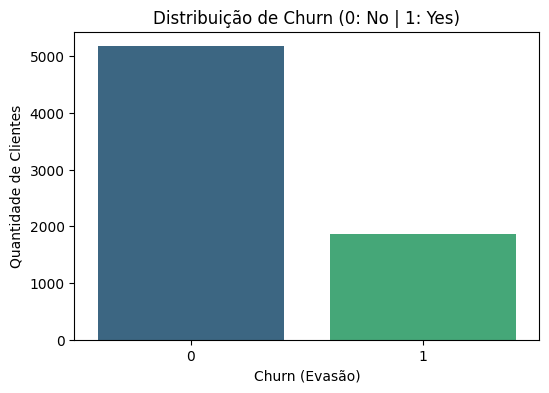

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Comando para esconder os avisos (warnings)
warnings.filterwarnings('ignore')

# Cálculo da proporção
proporcao = df['Churn'].value_counts(normalize=True) * 100

print("Proporção das Classes no Churn:")
for categoria, valor in proporcao.items():
    print(f"Categoria {categoria}: {valor:.2f}%")


# Gráfico:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Distribuição de Churn (0: No | 1: Yes)')
plt.ylabel('Quantidade de Clientes')
plt.xlabel('Churn (Evasão)')
plt.show()

1.6 - Balanceamento de Classes (SMOTE)

In [90]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separando os preditores (X) da variável alvo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Configurando o SMOTE
smt = SMOTE(random_state=42)

# Aplicando o balanceamento (criando os dados sintéticos)
X_res, y_res = smt.fit_resample(X, y)

# Criando um novo DataFrame com os dados equilibrados
df_balanced = pd.concat([X_res, y_res], axis=1)

print("Passo 1e (Balanceamento) concluído!")
print("-" * 30)
print("Nova proporção das classes no Churn:")
print(df_balanced['Churn'].value_counts(normalize=True) * 100)
print("-" * 30)
print(f"Total de registros ANTES: {df.shape[0]}")
print(f"Total de registros AGORA: {df_balanced.shape[0]}")

Passo 1e (Balanceamento) concluído!
------------------------------
Nova proporção das classes no Churn:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64
------------------------------
Total de registros ANTES: 7043
Total de registros AGORA: 10348


1.7 - Normalização

In [91]:
from sklearn.preprocessing import MinMaxScaler

# Normalizador
scaler = MinMaxScaler()
df_final = pd.DataFrame(scaler.fit_transform(df_balanced), columns=df_balanced.columns)

print("Parte 1 - Preparação dos Dados, Concluída")
print("-" * 40)
print("Amostra dos dados normalizados:")

# Mostrando apenas algumas colunas para conferência
display(df_final[['Tenure', 'ChargesMonthly']].head())

Parte 1 - Preparação dos Dados, Concluída
----------------------------------------
Amostra dos dados normalizados:


,Tenure,ChargesMonthly
0,0.125000,0.471144
1,0.125000,0.414428
2,0.055556,0.553731
3,0.180556,0.793532
4,0.041667,0.653234


## 📊 EDA

✔️ Correlação entre variaveis numericas

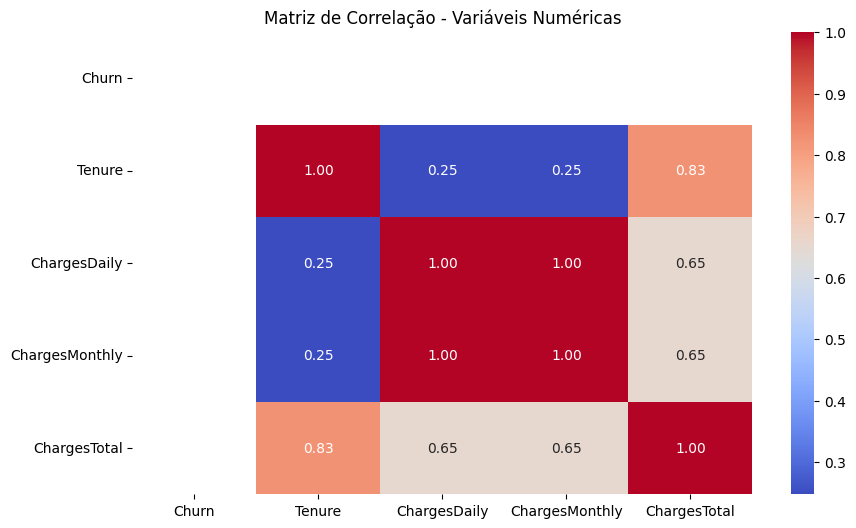

In [92]:
# Selecionar apenas variáveis numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"])

# Converter Churn para numérico
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


# Calcular matriz de correlação
corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()


In [93]:
df = df.drop(columns=["ChargesDaily", "ChargesTotal"])

2️⃣ Análise de churn por categoria (variáveis categóricas)

🔹 Selecionar variáveis categóricas

In [94]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")


KeyError: "['Churn'] not found in axis"

🔹 Tabela de proporção de churn por categoria

In [ ]:
for col in categorical_cols:
    print(f"\n📌 Análise da variável: {col}")
    #Ele cria uma tabela de porcentagem de churn dentro de cada categoria de uma variável.
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"Distribuição de Churn por {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Criar cópia
df_rank = df.copy()

# Converter Churn para binário
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variáveis categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporário (apenas para teste estatístico)
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-quadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variável": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importância
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df
